CPI index sample: [Timestamp('2000-01-01 00:00:00'), Timestamp('2000-02-01 00:00:00'), Timestamp('2000-03-01 00:00:00')]
BigMac index sample: [Timestamp('2000-04-01 00:00:00'), Timestamp('2000-05-01 00:00:00'), Timestamp('2000-06-01 00:00:00')]
Merged observations: 256
            dollar_price  bm_yoy   cpi_yoy
date                                      
2001-04-01          2.24     0.0  3.218256
2001-05-01          2.24     0.0  3.563084
2001-06-01          2.24     0.0  3.193961
2001-07-01          2.24     0.0  2.721482
2001-08-01          2.24     0.0  2.721482


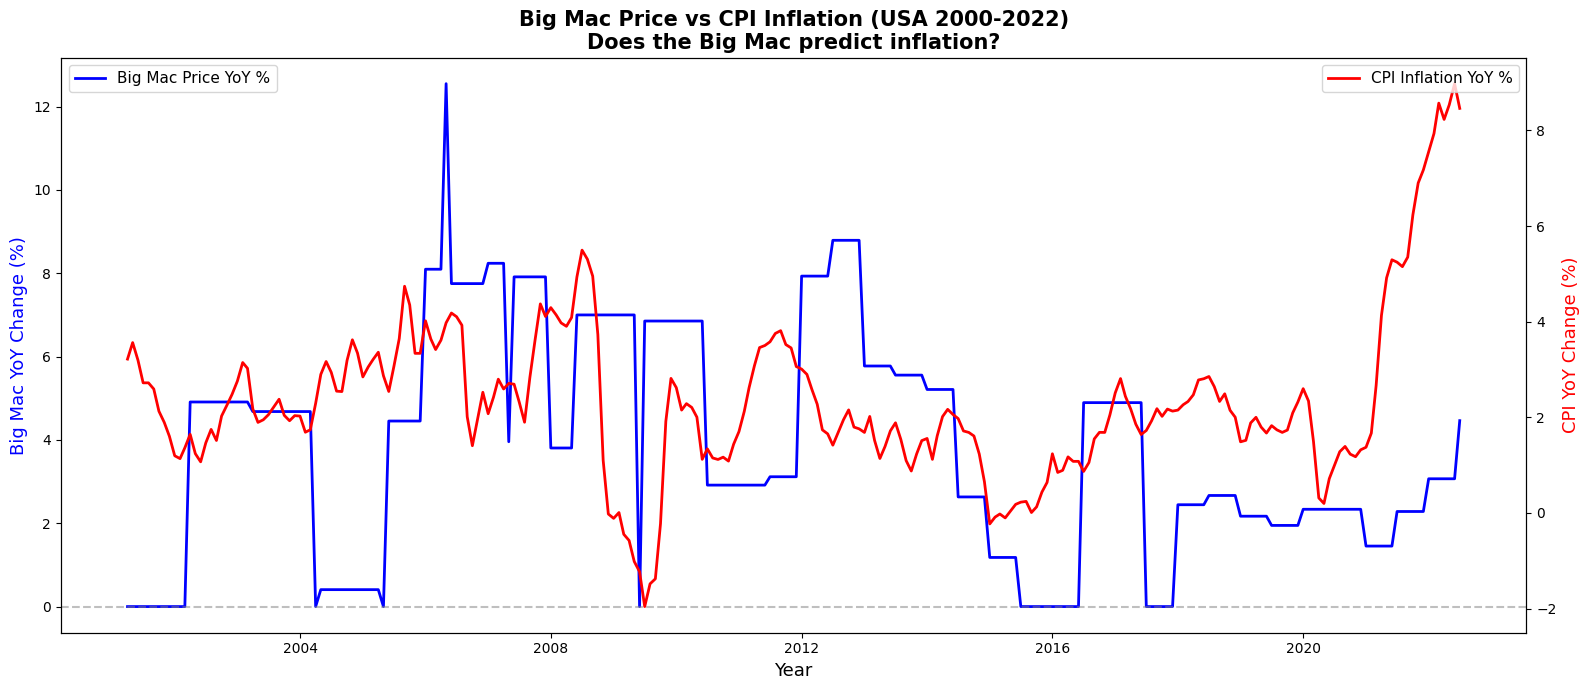

Regression observations: 250


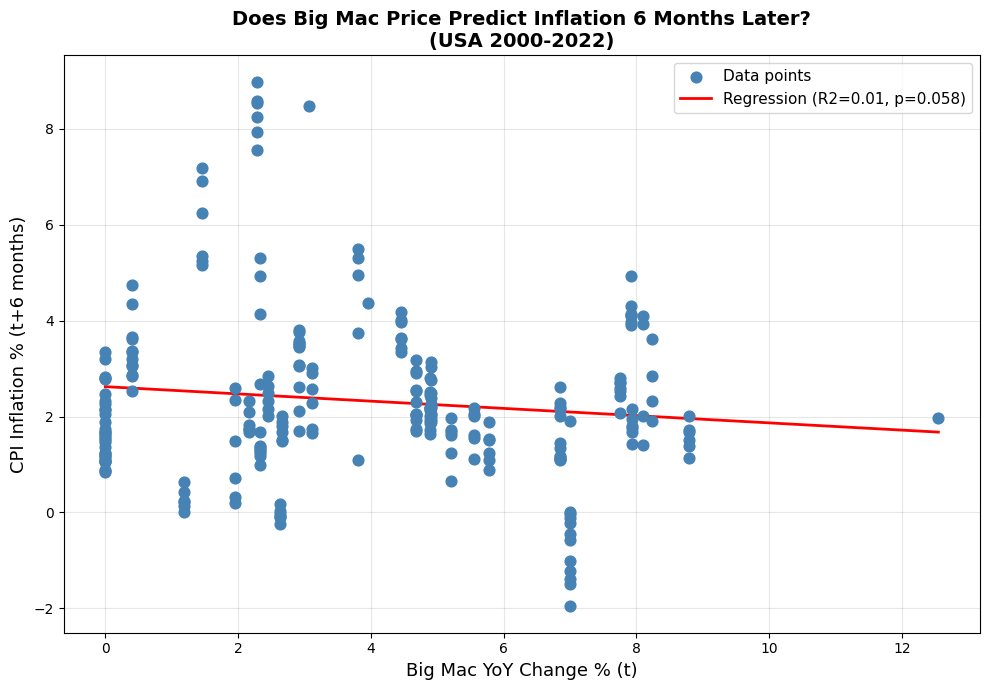

ALTERNATIVE DATA ALPHA: BIG MAC -> INFLATION
Observations: 250
R2 = 0.014  (1.4% variance explained)
p-value = 0.0584  (not significant at 5% level)
Slope = -0.075
Correlation = -0.120


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Load Big Mac data
raw_data = pd.read_csv('/kaggle/input/datasets/ayyazahmed866/bigmacprice/BigmacPrice.csv')
data = raw_data.drop(columns=['currency_code', 'local_price', 'dollar_ex'])
data = data.rename(columns={'name': 'country'})

# Load CPI
cpi = pd.read_csv('/kaggle/input/datasets/ayyazahmed866/fredgraph/CPIAUCSL.csv')
cpi.columns = ['date', 'CPIAUCSL']
cpi['date'] = pd.to_datetime(cpi['date'])
cpi = cpi.set_index('date')
cpi = cpi.loc['2000':'2022']
cpi['cpi_yoy'] = cpi['CPIAUCSL'].pct_change(12) * 100
cpi.index = cpi.index.to_period('M').to_timestamp()

# Prep Big Mac USA - resample to monthly
us_bm = data[data['country'] == 'United States'].copy()
us_bm['date'] = pd.to_datetime(us_bm['date'])
us_bm = us_bm.sort_values('date').set_index('date')
us_bm_monthly = us_bm[['dollar_price']].resample('MS').last().ffill()
us_bm_monthly['bm_yoy'] = us_bm_monthly['dollar_price'].pct_change(12) * 100

# Debug prints
print("CPI index sample:", cpi.index[:3].tolist())
print("BigMac index sample:", us_bm_monthly.index[:3].tolist())

# Merge
merged = us_bm_monthly.join(cpi[['cpi_yoy']], how='inner').dropna()
print("Merged observations:", len(merged))
print(merged.head())

# Dual axis chart
fig, ax1 = plt.subplots(figsize=(16, 7))
ax2 = ax1.twinx()
ax1.plot(merged.index, merged['bm_yoy'], 'b-', linewidth=2, label='Big Mac Price YoY %')
ax2.plot(merged.index, merged['cpi_yoy'], 'r-', linewidth=2, label='CPI Inflation YoY %')
ax1.set_ylabel('Big Mac YoY Change (%)', color='b', fontsize=13)
ax2.set_ylabel('CPI YoY Change (%)', color='r', fontsize=13)
ax1.set_xlabel('Year', fontsize=13)
ax1.legend(loc='upper left', fontsize=11)
ax2.legend(loc='upper right', fontsize=11)
ax1.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.title('Big Mac Price vs CPI Inflation (USA 2000-2022)\nDoes the Big Mac predict inflation?',
          fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Scatter + regression (Big Mac lagged 6 months)
merged['bm_yoy_lag6'] = merged['bm_yoy'].shift(6)
clean = merged[['bm_yoy_lag6', 'cpi_yoy']].dropna()
print("Regression observations:", len(clean))

slope, intercept, r_value, p_value, std_err = stats.linregress(
    clean['bm_yoy_lag6'], clean['cpi_yoy'])

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(clean['bm_yoy_lag6'], clean['cpi_yoy'],
           color='steelblue', s=60, zorder=3, label='Data points')
x_line = np.linspace(clean['bm_yoy_lag6'].min(), clean['bm_yoy_lag6'].max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, 'r-', linewidth=2,
        label=f'Regression (R2={r_value**2:.2f}, p={p_value:.3f})')
ax.set_xlabel('Big Mac YoY Change % (t)', fontsize=13)
ax.set_ylabel('CPI Inflation % (t+6 months)', fontsize=13)
ax.set_title('Does Big Mac Price Predict Inflation 6 Months Later?\n(USA 2000-2022)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary
print("=" * 50)
print("ALTERNATIVE DATA ALPHA: BIG MAC -> INFLATION")
print("=" * 50)
print(f"Observations: {len(clean)}")
print(f"R2 = {r_value**2:.3f}  ({r_value**2*100:.1f}% variance explained)")
print(f"p-value = {p_value:.4f}  ({'SIGNIFICANT' if p_value < 0.05 else 'not significant'} at 5% level)")
print(f"Slope = {slope:.3f}")
corr = clean['bm_yoy_lag6'].corr(clean['cpi_yoy'])
print(f"Correlation = {corr:.3f}")
print("=" * 50)